# The Determinant As an Area

*Course notes for **Math for Machine Learning**, C1 · W4 · L1 · V03 — "The Determinant As an Area" (DeepLearning.AI).*

Through the lens of linear transformations, the **determinant** gets a wonderfully concrete meaning: it is the **area** (in 2D — or **volume** in higher dimensions) of the image of the unit square. When that area is $0$, the matrix is **singular**. We cover:

- Determinant $=$ area of the transformed unit square.
- Singular matrices $\Rightarrow$ area $0$ (line or point).
- **Negative** determinants as **signed area** (orientation), and why only $\det = 0$ matters for singularity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. Determinant = area of the image of the unit square

For $A = \begin{pmatrix} 3 & 1 \\ 1 & 2 \end{pmatrix}$ the determinant is

$$ \det(A) = 3\cdot 2 - 1\cdot 1 = 5. $$

The unit square (area $1$) maps to a parallelogram whose **area is exactly $5$** — the determinant. In general:

> **The determinant of a matrix is the area of the image of the fundamental unit square.**

In [2]:
A = np.array([[3, 1],
              [1, 2]])
print('det(A) =', np.linalg.det(A))

# The parallelogram is spanned by the columns of A; its area is |det|.
col1, col2 = A[:, 0], A[:, 1]
cross = col1[0]*col2[1] - col1[1]*col2[0]   # z-component of the cross product
print('area of parallelogram (|cross of columns|) =', abs(cross))

det(A) = 5.000000000000001
area of parallelogram (|cross of columns|) = 5


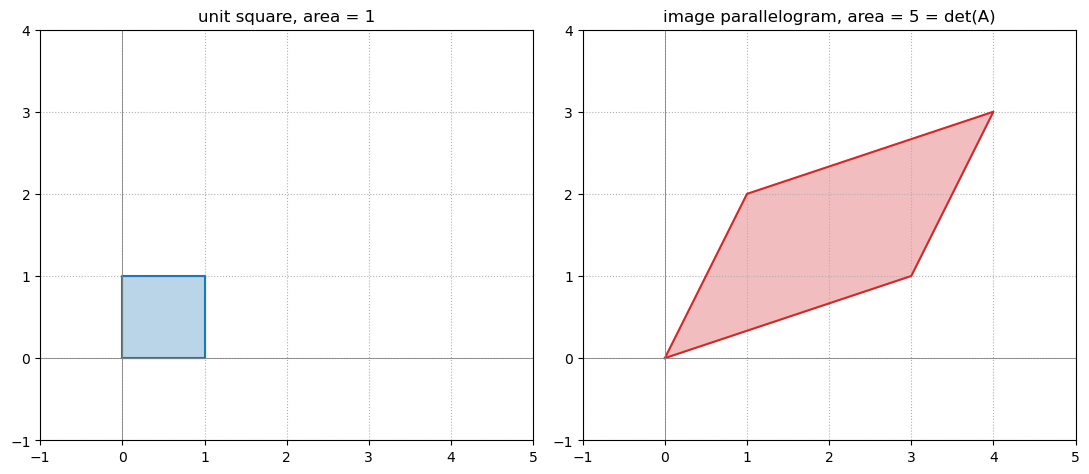

In [3]:
# Visualize: unit square (area 1) -> parallelogram (area 5)
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T
img = A @ square

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].fill(square[0], square[1], color='C0', alpha=0.3); axes[0].plot(square[0], square[1], 'C0')
axes[0].set_title('unit square, area = 1')
axes[1].fill(img[0], img[1], color='C3', alpha=0.3); axes[1].plot(img[0], img[1], 'C3')
axes[1].set_title(f'image parallelogram, area = {np.linalg.det(A):.0f} = det(A)')
for ax in axes:
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.set_xlim(-1, 5); ax.set_ylim(-1, 4)
plt.tight_layout(); plt.show()

## 2. Singular matrices have area $0$

- $\begin{pmatrix} 1 & 1 \\ 2 & 2 \end{pmatrix}$: $\det = 1\cdot 2 - 1\cdot 2 = 0$. The square maps to an infinitely thin parallelogram — a **line segment** with area $0$.
- The **zero matrix** $\begin{pmatrix} 0 & 0 \\ 0 & 0 \end{pmatrix}$: $\det = 0$. The square maps to a single **point**, area $0$.

In both cases $\det = 0$ — the geometric signature of singularity.

In [4]:
S = np.array([[1, 1], [2, 2]])
Z = np.array([[0, 0], [0, 0]])
print('det(S) =', np.linalg.det(S), ' -> image is a line, area 0 (singular)')
print('det(Z) =', np.linalg.det(Z), ' -> image is a point, area 0 (singular)')

det(S) = 0.0  -> image is a line, area 0 (singular)
det(Z) = 0.0  -> image is a point, area 0 (singular)


## 3. Negative determinants: signed area and orientation

What about **negative** determinants? Permuting (swapping) the two columns of a matrix **negates** its determinant. Compare $A$ with the column-swapped $\begin{pmatrix} 1 & 3 \\ 2 & 1 \end{pmatrix}$, which sends $(1,0)\mapsto(1,2)$ and $(0,1)\mapsto(3,1)$ — the same two vectors as $A$ but in the **opposite order**:

$$ \det\begin{pmatrix} 1 & 3 \\ 2 & 1 \end{pmatrix} = 1\cdot 1 - 3\cdot 2 = -5. $$

The determinant is a **signed** area. The sign records **orientation**: it is one sign if the basis vectors are taken counterclockwise and the other if clockwise. Swapping the columns flips the orientation, hence the sign.

Crucially, **the sign does not affect singularity** — all that matters is whether $\det = 0$. A matrix is non-singular precisely when $\det \neq 0$, positive **or** negative.

In [5]:
A_swapped = A[:, ::-1]   # swap the two columns
print('A =\n', A, '  det =', np.linalg.det(A))
print('A with columns swapped =\n', A_swapped, '  det =', np.linalg.det(A_swapped))
print()
print('|det| is the same (area 5); only the SIGN (orientation) flipped.')
print('both are non-singular because det != 0.')

A =
 [[3 1]
 [1 2]]   det = 5.000000000000001
A with columns swapped =
 [[1 3]
 [2 1]]   det = -5.000000000000001

|det| is the same (area 5); only the SIGN (orientation) flipped.
both are non-singular because det != 0.


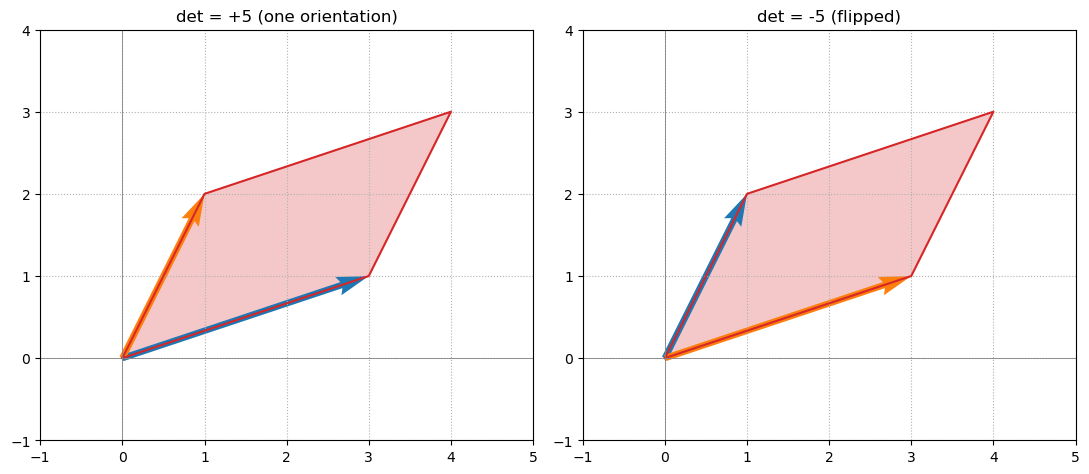

In [6]:
# Same parallelogram shape, opposite orientation (sign of the area)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
opts = dict(angles='xy', scale_units='xy', scale=1, width=0.013)
for ax, Mx, ttl in [(axes[0], A, f'det = +{np.linalg.det(A):.0f} (one orientation)'),
                    (axes[1], A_swapped, f'det = {np.linalg.det(A_swapped):.0f} (flipped)')]:
    img = Mx @ square
    ax.fill(img[0], img[1], color='C3', alpha=0.25); ax.plot(img[0], img[1], 'C3')
    ax.quiver(0, 0, *Mx[:, 0], color='C0', **opts)   # first column
    ax.quiver(0, 0, *Mx[:, 1], color='C1', **opts)   # second column
    ax.set_title(ttl)
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.set_xlim(-1, 5); ax.set_ylim(-1, 4)
plt.tight_layout(); plt.show()

## Summary

- The **determinant is the (signed) area** of the image of the unit square — the volume in higher dimensions.
- **$\det = 0 \iff$ singular**: the square collapses to a **line** (area $0$) or a **point** (area $0$).
- A **negative determinant** just means the transformation **flipped orientation** (e.g. swapping two columns negates it); the magnitude $|\det|$ is still the area.
- Only **$\det = 0$** signals singularity — the sign is irrelevant to invertibility. Non-singular $\iff \det \neq 0$.